In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:


import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# CatBoost

El algoritmo **CatBoost** (Categorical Boosting) es una implementación altamente eficiente, escalable y robusta de los **Gradient Boosting Decision Trees (GBDT)**, desarrollado por Yandex. Es un potente método de **aprendizaje de conjunto (*ensemble*)** que utiliza la estrategia de **Boosting**.

CatBoost es una alternativa recomendada para XGBoost y LightGBM, siendo reconocido por su alto rendimiento, especialmente en tareas con una gran cantidad de características categóricas.

Bases del Algoritmo CatBoost

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   Al igual que otras implementaciones de GBDT, CatBoost entrena secuencialmente una serie de árboles de decisión, donde cada nuevo árbol se enfoca en **corregir los errores** de la suma acumulada de los modelos anteriores.

2.  **Manejo Nativo de Características Categóricas (Innovación Principal):**
    *   La característica más distintiva de CatBoost es su **soporte nativo para variables categóricas** (*out of the box*). No requiere pre-codificación manual de estas características antes del entrenamiento.
    *   CatBoost transforma las características categóricas en valores numéricos **internamente**. Este proceso utiliza un método único de codificación que es similar al **alisado aditivo** (*additive smoothing*).

3.  **Eficiencia y Robustez:**
    *   CatBoost está diseñado para ser eficiente y es una de las implementaciones que se recomienda considerar para **grandes conjuntos de datos de series temporales**.
    *   Junto con LightGBM, CatBoost a menudo se menciona como una de las implementaciones que ha logrado **superar las métricas de XGBoost** en ciertos casos.
    *   El algoritmo también **maneja los valores faltantes de forma nativa**.

En resumen, CatBoost sobresale de sus competidores por su **tratamiento avanzado y robusto de las variables categóricas** directamente en el proceso de *boosting*, lo que elimina la necesidad de ingeniería de características manual para estos tipos de datos y produce un modelo final muy preciso.




# Prearación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST


# CatBoos global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:

# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (CatBoost)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: CATBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



🔍 MODELO 1: CATBOOST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA CATBOOST
# =====================================================

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...")
start_time = time.perf_counter()

study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=5, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros CatBoost:")
print(study_catboost.best_params)


[I 2025-12-01 22:30:54,843] A new study created in memory with name: no-name-6909dea1-fd3d-4e1a-bd0d-4a107a9d80b9



🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...

🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...


[I 2025-12-01 22:31:46,248] Trial 0 finished with value: 3.889571823699893 and parameters: {'iterations': 1051, 'learning_rate': 0.017005369459176058, 'depth': 8, 'l2_leaf_reg': 3.4500460003375664, 'bagging_temperature': 0.08948717973599984, 'random_strength': 8.612856253897473, 'border_count': 181, 'min_data_in_leaf': 74}. Best is trial 0 with value: 3.889571823699893.
[I 2025-12-01 22:31:55,189] Trial 1 finished with value: 3.9058961815792146 and parameters: {'iterations': 303, 'learning_rate': 0.09535022525559282, 'depth': 4, 'l2_leaf_reg': 6.709525712233868, 'bagging_temperature': 0.9356436319636613, 'random_strength': 6.909198422715669, 'border_count': 68, 'min_data_in_leaf': 9}. Best is trial 0 with value: 3.889571823699893.
[I 2025-12-01 22:31:55,189] Trial 1 finished with value: 3.9058961815792146 and parameters: {'iterations': 303, 'learning_rate': 0.09535022525559282, 'depth': 4, 'l2_leaf_reg': 6.709525712233868, 'bagging_temperature': 0.9356436319636613, 'random_strength': 6

✅ Optuna completado en 115.13 segundos

🏆 Mejores hiperparámetros CatBoost:
{'iterations': 903, 'learning_rate': 0.035236353761498335, 'depth': 9, 'l2_leaf_reg': 8.423655458489892, 'bagging_temperature': 0.3383946859125304, 'random_strength': 3.8863990888997213, 'border_count': 184, 'min_data_in_leaf': 78}


In [9]:
best_catboost = CatBoostRegressor(
    **study_catboost.best_params,
    random_state=42)

best_catboost.fit(X_train, y_train, verbose=False)


In [10]:

from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_catboost.predict(X_test)

# Calcular métricas
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='CatBoost', ndetalle='Global', cluster=None, producto=None)

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='CatBoost', ndetalle='Global', cluster= cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='CatBoost',
            ndetalle='Global', cluster=cluster, producto=producto) 

resumen_metricas(todas_metricas)    





📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost   Global    None     None 1.5772 2.3828 0.2591     49.53     144.41 0.7302    96.59

🏆 Mejor modelo: CatBoost (RMSE: 2.3828)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost   Global      3.0     None 1.0861 1.6512 0.0864     55.06     168.86 0.7410   133.74
 CatBoost   Global      NaN     None 1.5772 2.3828 0.2591     49.53     144.41 0.7302    96.59
 CatBoost   Global      0.0     None 1.8159 2.5866 0.0911     40.14     125.80 0.7436    94.04
 CatBoost   Global      1.0     None 2.7703 3.5818 0.1467     55.30      98.25 0.7159    72.65
 CatBoost   Global      2.0     None 3.6411 5.1105 0.1929     72.90      80.81 0.7107    63.40

🏆 Mejor modelo: CatBoost (RMSE: 1.6512)


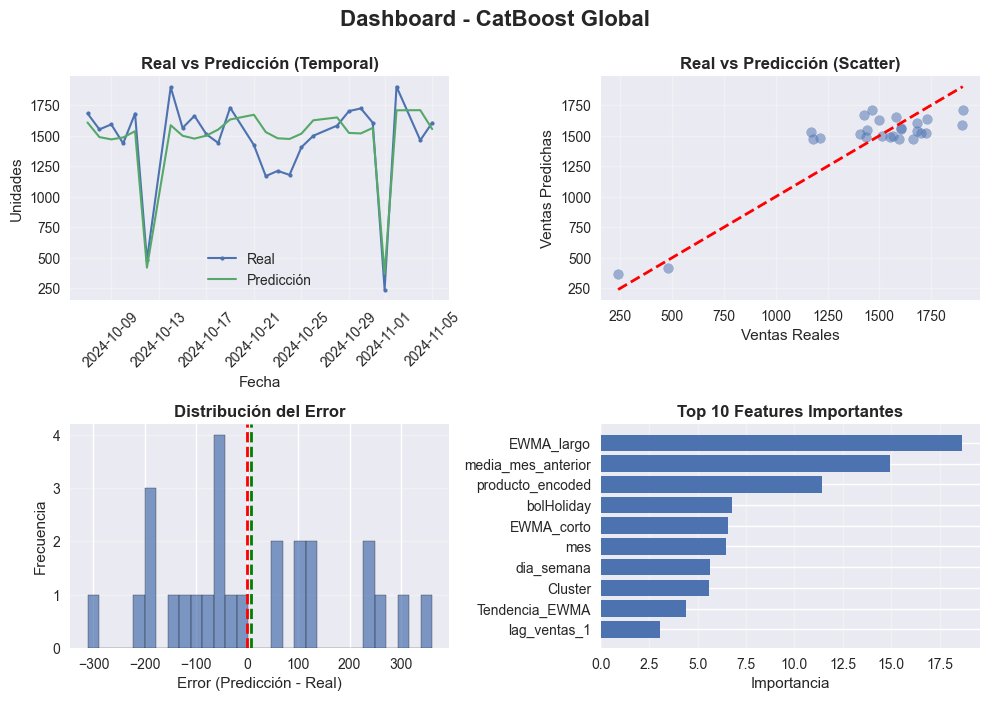

In [11]:

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_catboost,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - CatBoost Global',
        figsize=(10, 7)
        )


# CatBoost por Cluster


🔍 MODELO 2: CATBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        0     None 1.8131 2.5449 0.1202     40.05      125.7 0.7316     93.9

🏆 Mejor modelo: CatBoost (RMSE: 2.5449)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        0     None 1.8131 2.5449 0.1202     40.05      125.7 0.7316     93.9

🏆 Mejor modelo: CatBoost (RMSE: 2.5449)


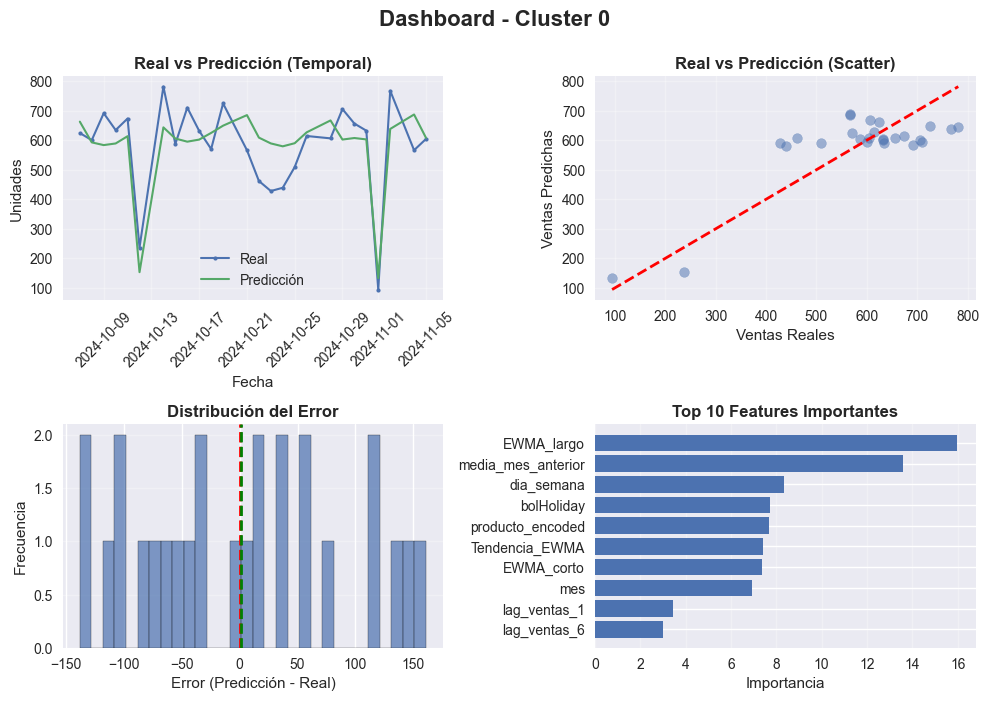


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        1     None 2.7791 3.5918 0.1419      55.6      98.33 0.7179    72.88

🏆 Mejor modelo: CatBoost (RMSE: 3.5918)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        1     None 2.7791 3.5918 0.1419      55.6      98.33 0.7179    72.88

🏆 Mejor modelo: CatBoost (RMSE: 3.5918)


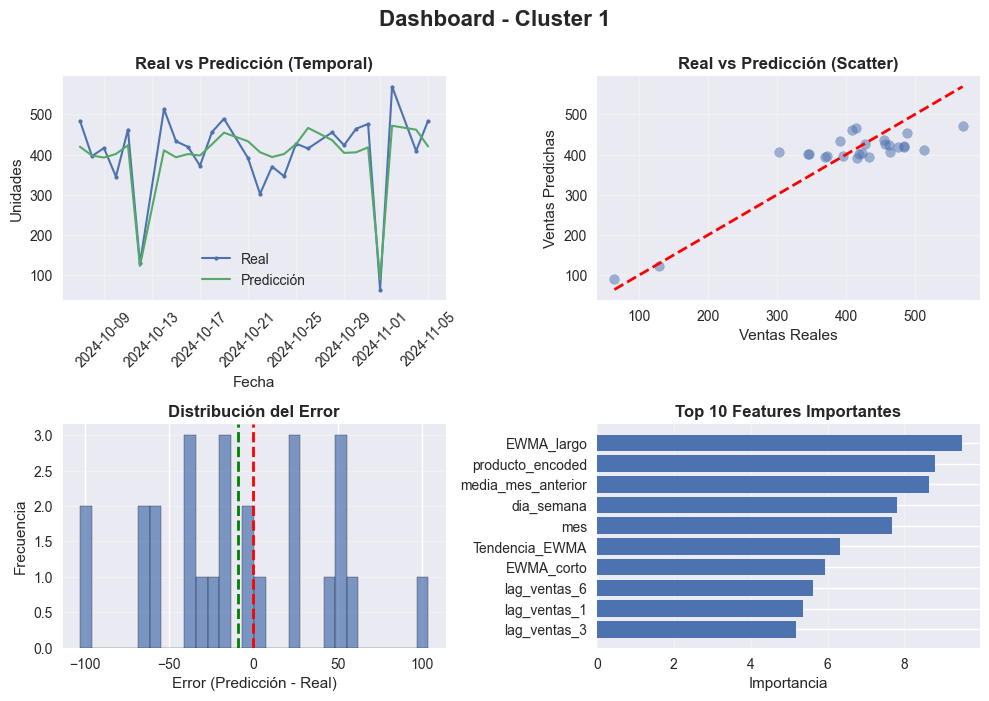


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        2     None 3.6655  5.12 0.1899     73.62      81.09  0.712    63.83

🏆 Mejor modelo: CatBoost (RMSE: 5.1200)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        2     None 3.6655  5.12 0.1899     73.62      81.09  0.712    63.83

🏆 Mejor modelo: CatBoost (RMSE: 5.1200)


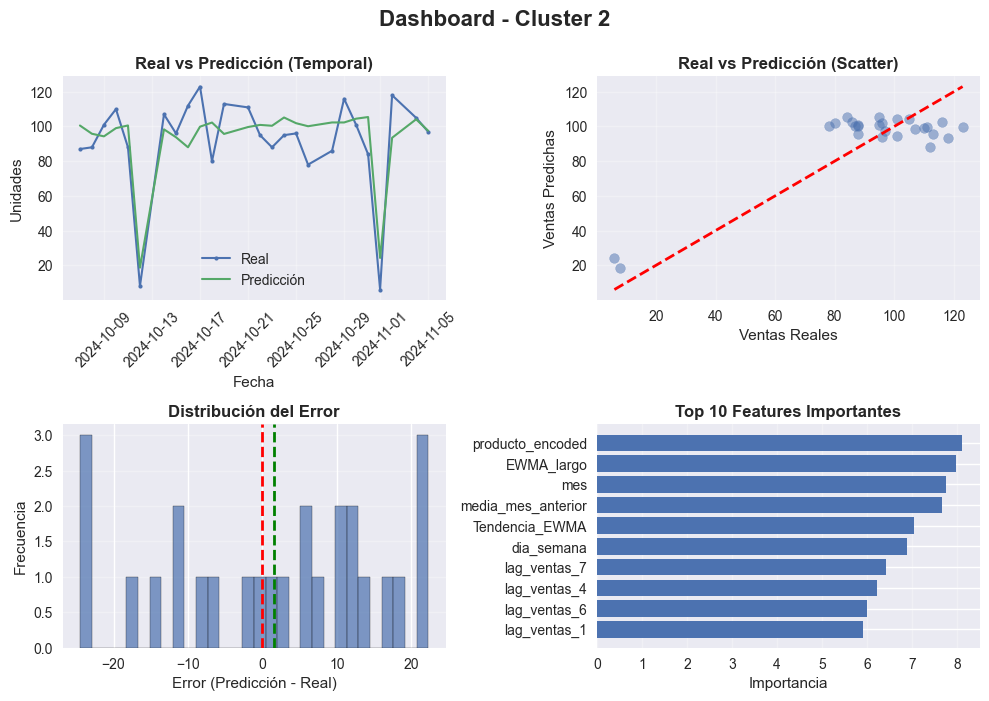


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        3     None 1.0899 1.669 0.0666     55.21      168.9  0.749    134.2

🏆 Mejor modelo: CatBoost (RMSE: 1.6690)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        3     None 1.0899 1.669 0.0666     55.21      168.9  0.749    134.2

🏆 Mejor modelo: CatBoost (RMSE: 1.6690)


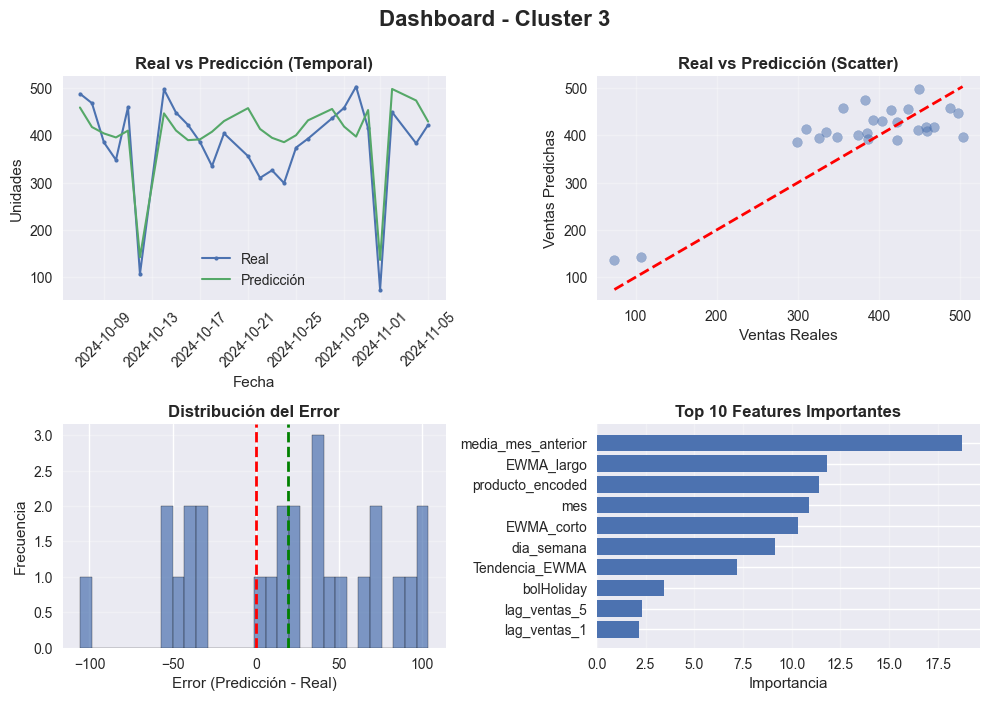

In [12]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: CATBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    catboost_cluster = CatBoostRegressor(
        **study_catboost.best_params,
        random_state=42)
    
    catboost_cluster.fit(X_train_c, y_train_c, verbose=False)
    y_pred_c = catboost_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="CatBoost", ndetalle='Cluster',cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='CatBoost',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=catboost_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )



# CatBoost por top 2 productos de ventas por cluster


📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       413 1.9158 2.3086 -0.1011     45.79     110.97 0.8082    92.24

🏆 Mejor modelo: CatBoost (RMSE: 2.3086)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       413 1.9158 2.3086 -0.1011     45.79     110.97 0.8082    92.24

🏆 Mejor modelo: CatBoost (RMSE: 2.3086)


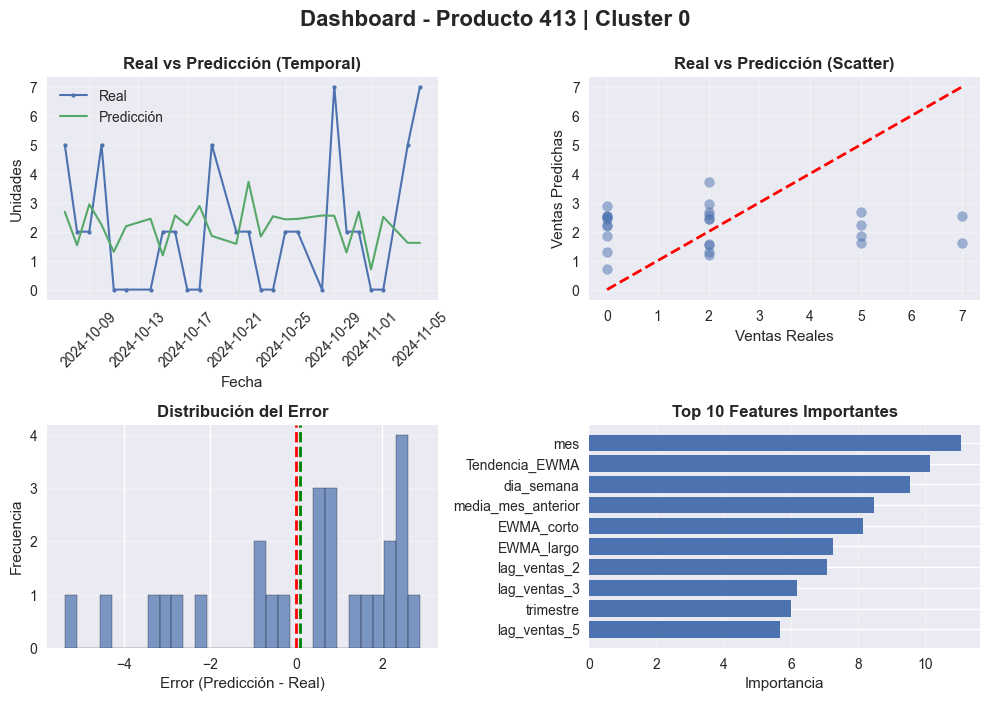


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       294 2.7587 3.4585 -0.4996     76.05     144.02 0.7968   149.43

🏆 Mejor modelo: CatBoost (RMSE: 3.4585)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       294 2.7587 3.4585 -0.4996     76.05     144.02 0.7968   149.43

🏆 Mejor modelo: CatBoost (RMSE: 3.4585)


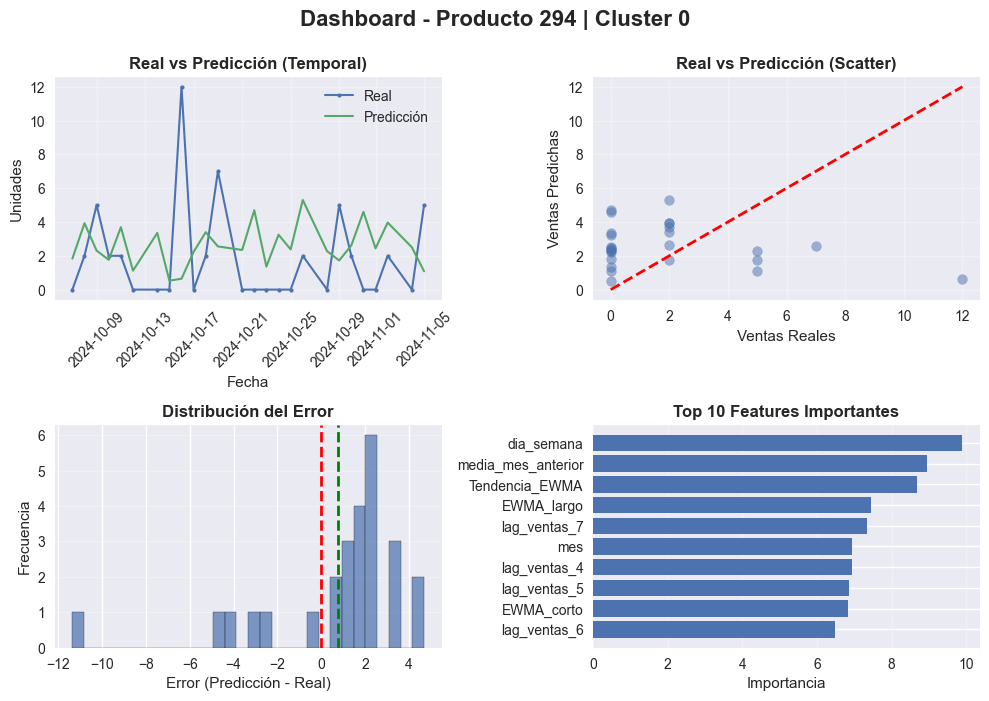


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1       144 3.8317 4.8605 0.0803     81.85      83.38 0.7265    67.77

🏆 Mejor modelo: CatBoost (RMSE: 4.8605)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1       144 3.8317 4.8605 0.0803     81.85      83.38 0.7265    67.77

🏆 Mejor modelo: CatBoost (RMSE: 4.8605)


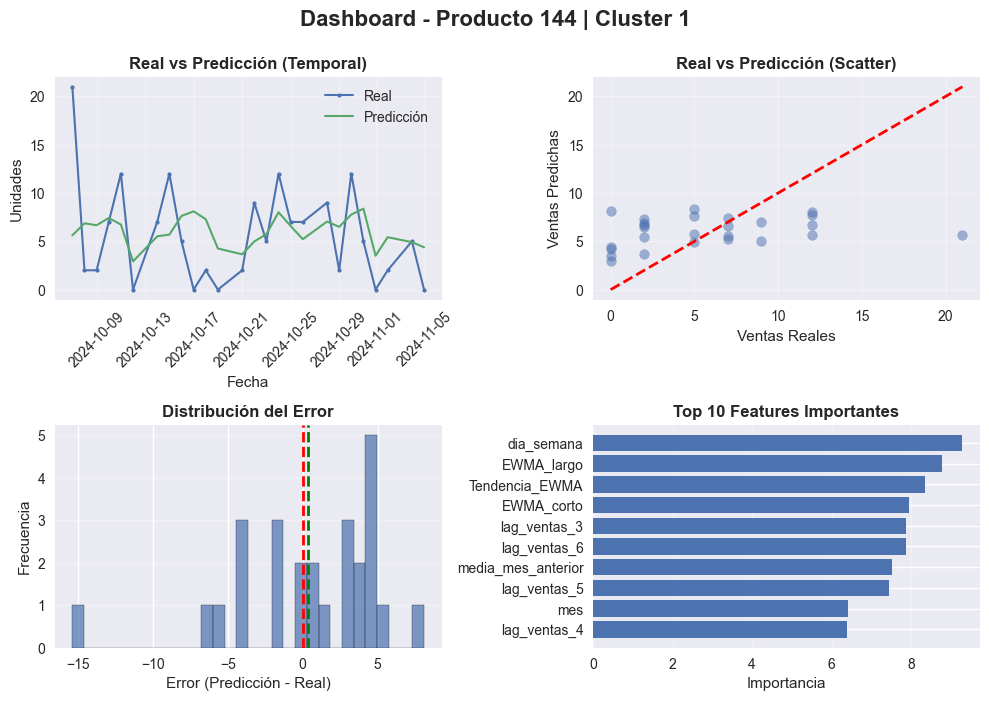


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1        41 3.5289 4.613 -0.0436     61.31      65.91 0.7874    53.34

🏆 Mejor modelo: CatBoost (RMSE: 4.6130)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1        41 3.5289 4.613 -0.0436     61.31      65.91 0.7874    53.34

🏆 Mejor modelo: CatBoost (RMSE: 4.6130)


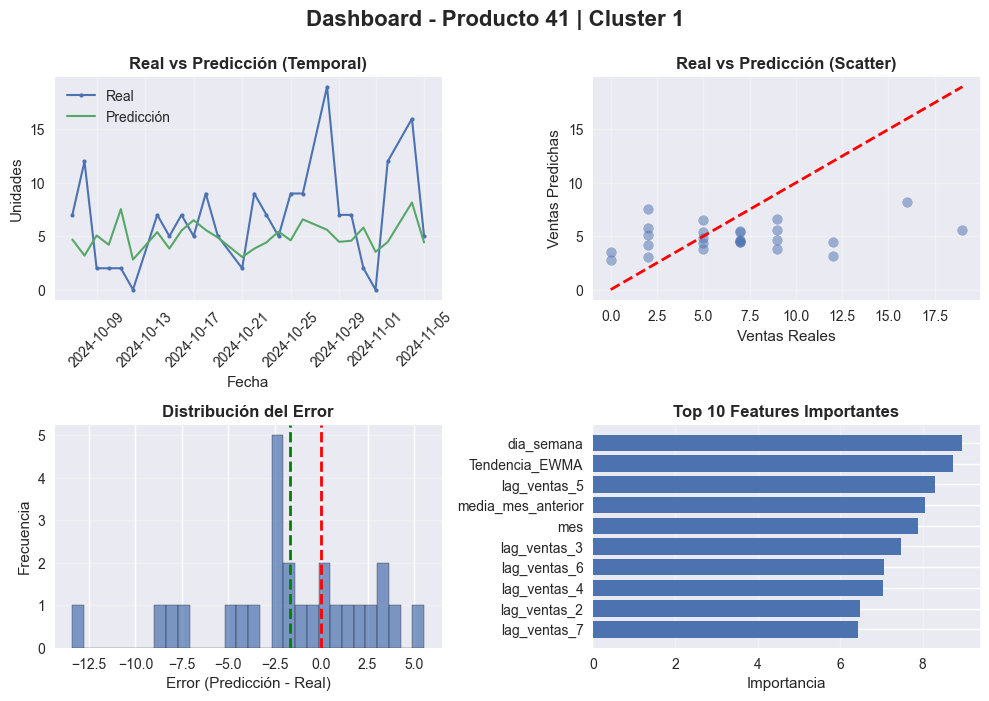


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         1 8.3336 11.7622 -0.115    112.88      73.25 0.7405    70.58

🏆 Mejor modelo: CatBoost (RMSE: 11.7622)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         1 8.3336 11.7622 -0.115    112.88      73.25 0.7405    70.58

🏆 Mejor modelo: CatBoost (RMSE: 11.7622)


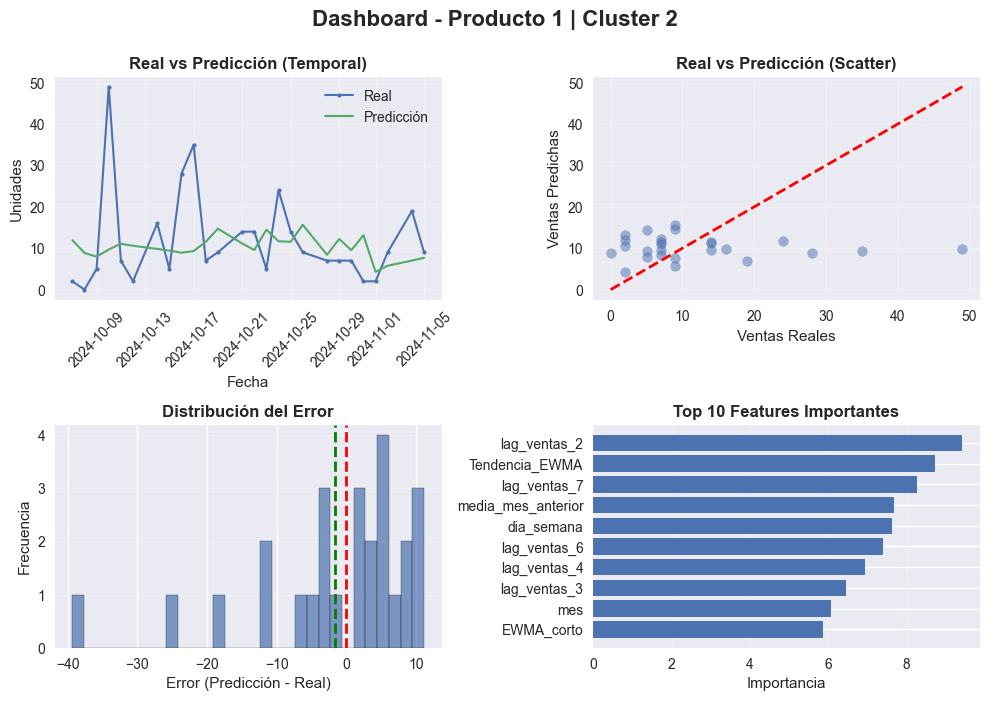


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         2 3.7959 4.6896 -0.0758     83.92      67.15 0.6516    60.18

🏆 Mejor modelo: CatBoost (RMSE: 4.6896)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         2 3.7959 4.6896 -0.0758     83.92      67.15 0.6516    60.18

🏆 Mejor modelo: CatBoost (RMSE: 4.6896)


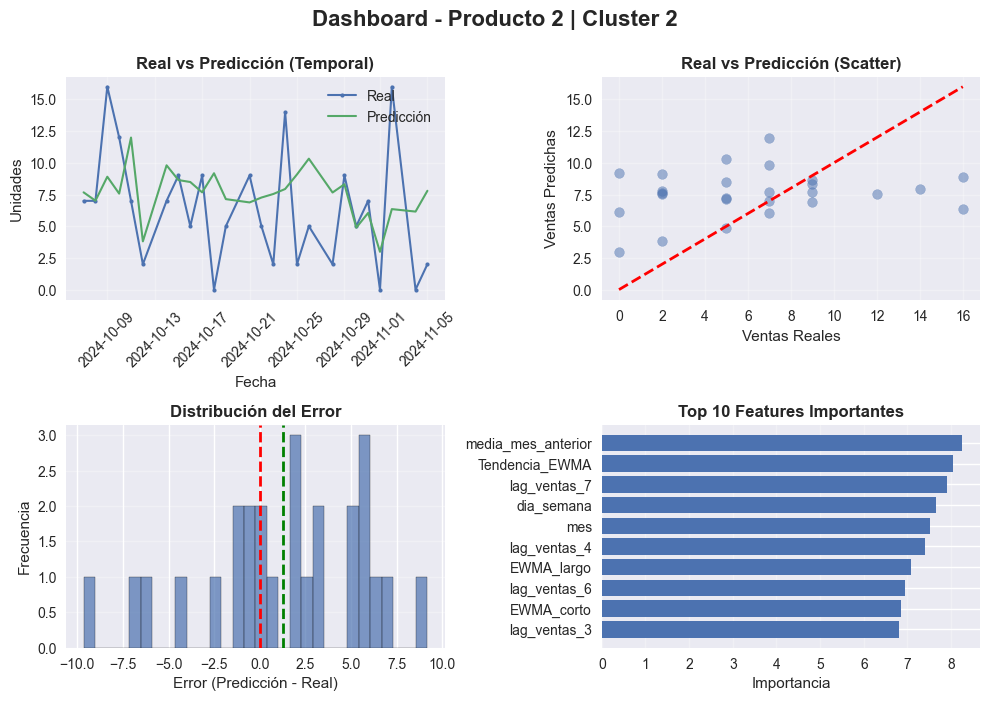


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       257 1.1657 1.6635 -1.0854     57.85     180.17 1.1319   233.15

🏆 Mejor modelo: CatBoost (RMSE: 1.6635)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       257 1.1657 1.6635 -1.0854     57.85     180.17 1.1319   233.15

🏆 Mejor modelo: CatBoost (RMSE: 1.6635)


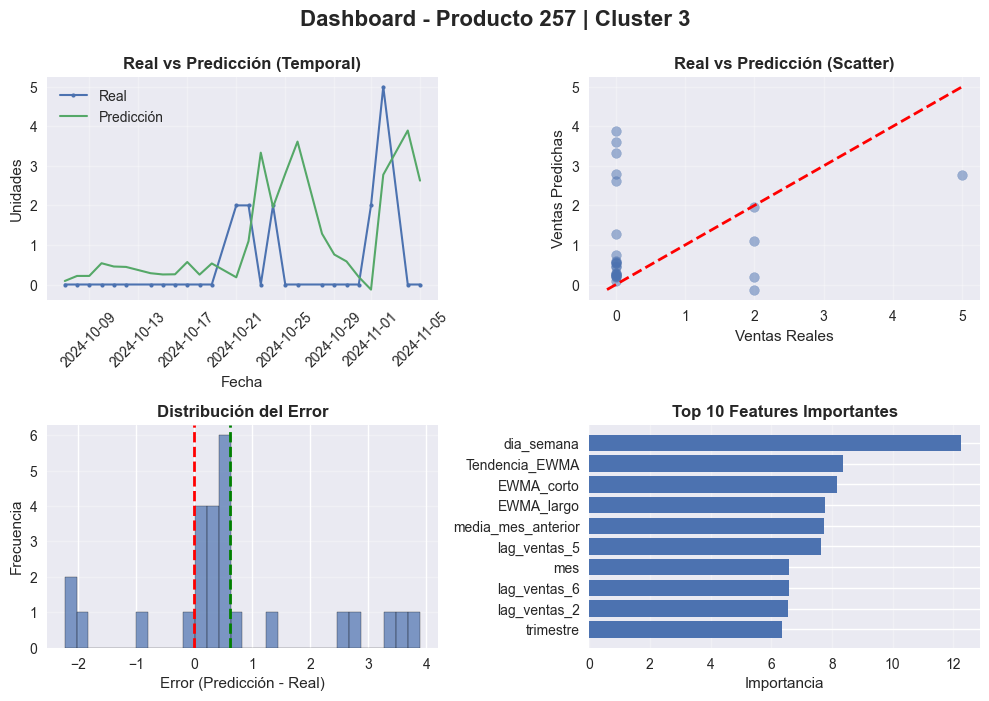


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       314 0.3015 0.3374 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: CatBoost (RMSE: 0.3374)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       314 0.3015 0.3374 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: CatBoost (RMSE: 0.3374)


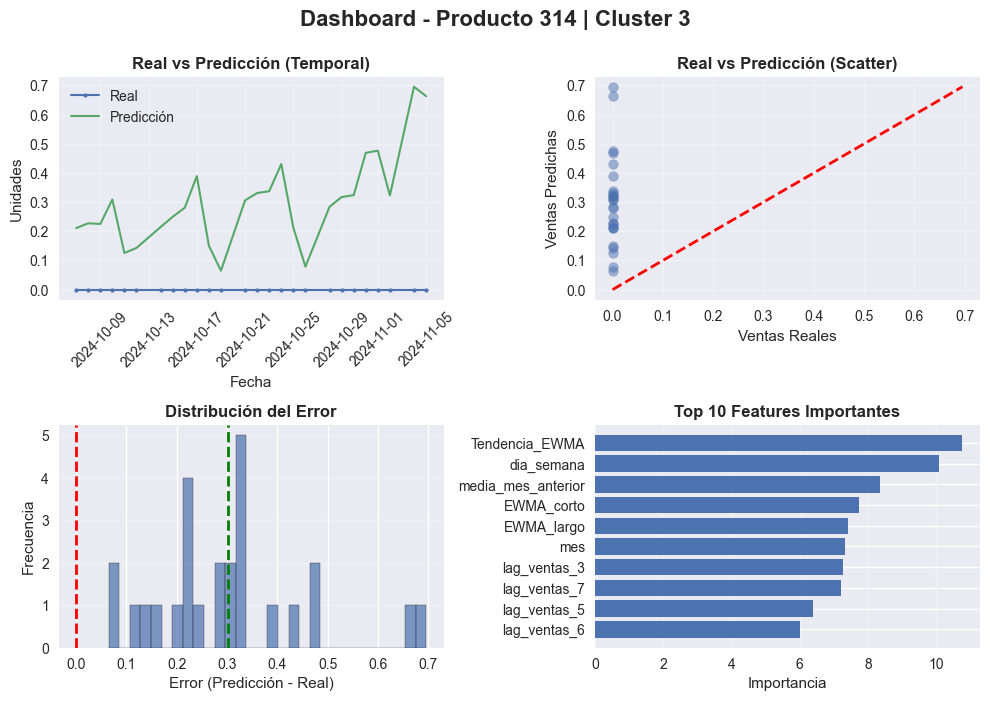


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        catboost_prod = CatBoostRegressor(
            **study_catboost.best_params,
            random_state=42)
        
        catboost_prod.fit(X_train_p, y_train_p, verbose=False)
        y_pred_p = catboost_prod.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = catboost_prod
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="CatBoost",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=catboost_prod,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

In [14]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

import plotly.express as px

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Tabla completa de métricas con metadatos
    print("\n📊 Resumen de todas las métricas (todas las columnas):")
    df_comparacion_final = pd.DataFrame(todas_metricas).copy()

    # Asegurar columnas y ordenar por Algoritmo y NDetalle (y RMSE ascendente dentro)
    columnas = [
        'Algoritmo', 'NDetalle', 'Cluster', 'Producto',
        'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)'
    ]
    cols_exist = [c for c in columnas if c in df_comparacion_final.columns]

    # Reemplazar inf por NaN para ordenar correctamente
    df_comparacion_final = df_comparacion_final.replace([np.inf, -np.inf], np.nan)

    # Orden: Algoritmo, NDetalle, RMSE
    orden_cols = [c for c in ['Algoritmo', 'NDetalle', 'RMSE'] if c in df_comparacion_final.columns]
    df_comparacion_final = df_comparacion_final.sort_values(orden_cols, ascending=[True, True, True])

    print(df_comparacion_final[cols_exist].to_string(index=False))

    # Resúmenes por NDetalle
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS (NDetalle)")
    print("="*100)

    for nivel in ['Global', 'Cluster', 'Producto']:
        dfn = df_comparacion_final[df_comparacion_final['NDetalle'] == nivel]
        print(f"\n🔹 {nivel.upper()}:")
        if len(dfn) > 0:
            cols_nivel = ['Algoritmo', 'NDetalle', 'Cluster', 'Producto', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
            print(dfn[[c for c in cols_nivel if c in dfn.columns]].to_string(index=False))
            print(f"\n   Promedio RMSE: {dfn['RMSE'].mean():.2f}")
            if nivel == 'Cluster':
                print(f"   Mejor cluster: {dfn.loc[dfn['RMSE'].idxmin(), 'Cluster']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor cluster: {dfn.loc[dfn['RMSE'].idxmax(), 'Cluster']} (RMSE: {dfn['RMSE'].max():.2f})")
            if nivel == 'Producto':
                best_idx = dfn['RMSE'].idxmin(); worst_idx = dfn['RMSE'].idxmax()
                print(f"   Mejor producto: C{dfn.loc[best_idx, 'Cluster']} P{dfn.loc[best_idx, 'Producto']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor producto: C{dfn.loc[worst_idx, 'Cluster']} P{dfn.loc[worst_idx, 'Producto']} (RMSE: {dfn['RMSE'].max():.2f})")

    # Mejor modelo general (por RMSE)
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL (RMSE mínimo)")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]

    print(f"\n🏆 {mejor_modelo['Algoritmo']} | {mejor_modelo['NDetalle']}")
    print(f"   Cluster:    {mejor_modelo.get('Cluster', None)}")
    print(f"   Producto:   {mejor_modelo.get('Producto', None)}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   MSE:        {mejor_modelo['MSE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    print(f"   RMSSE:      {mejor_modelo['RMSSE']:.2f}")
    print(f"   MAE (%):    {mejor_modelo['MAE (%)']:.2f}")

else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if m.get('NDetalle') == 'Global'])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if m.get('NDetalle') == 'Cluster'])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if m.get('NDetalle') == 'Producto'])}")



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster      3.0     314.0 0.1655   0.0460  0.2145  0.0000       NaN     200.00    NaN      NaN
 CatBoost  Cluster      3.0     257.0 0.8867   1.3647  1.1682 -0.0285     76.96     186.47 0.7949   177.34
 CatBoost  Cluster      3.0       NaN 1.0899   2.7857  1.6690  0.0666     55.21     168.90 0.7490   134.20
 CatBoost  Cluster      0.0     413.0 1.7265   4.6805  2.1634  0.0330     34.44     102.46 0.7574    83.13
 CatBoost  Cluster      0.0       NaN 1.8131   6.4764  2.5449  0.1202     40.05     125.70 0.7316    93.90
 CatBoost  Cluster      0.0     294.0 2.2283   8.5115  2.9174 -0.0671     39.56     130.93 0.6721   120.70
 CatBoost  Cluster      1.0       NaN 2.7791  12.9011  3.5918  0.1419     55.60      98.33 0.7179    72.88
 CatBoost  Cluster      1.0      41.0

# Salvar resultados

In [15]:

# Salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_catboost.csv', index=False)
print("\nResultados guardados en 'datos/resultados_metricas_catboost.csv'")


Resultados guardados en 'datos/resultados_metricas_catboost.csv'
